***PROYECTO MACHINE LEARNING APLICADO AL ANALISIS DEL COVID-19***

El dataset COVID‑19 Dataset (Meir Nizri Kaggle) contiene información clínica y demográfica de más de 1 millón de pacientes relacionados con la pandemia de COVID-19. Este conjunto de datos fue recopilado a partir de registros de salud del gobierno de México e incluye variables sobre características del paciente, condiciones médicas preexistentes y resultados del tratamiento médico.

---



Integrantes:

Juan Andres Morera Ramirez-2243581

Diego Javier Quintero Ojeda-2243593

Johan Stip Chaparro Guerrero-2243677


# Análisis del Dataset COVID-19

## Introducción

El dataset COVID‑19 Dataset (Meir Nizri Kaggle) contiene información clínica y demográfica de más de 1 millón de pacientes relacionados con la pandemia de COVID-19. Este conjunto de datos fue recopilado a partir de registros de salud del gobierno de México e incluye variables sobre características del paciente, condiciones médicas preexistentes y resultados del tratamiento médico.

## Objetivo del Análisis

El objetivo principal de este análisis es explorar en profundidad la relación entre las características clínicas y demográficas de los pacientes y la gravedad del COVID-19, enfocándonos específicamente en la incidencia de neumonía. Se buscará identificar patrones robustos que permitan comprender mejor los factores de riesgo asociados con esta complicación. Esto incluye el análisis de variables demográficas como la edad, así como condiciones médicas preexistentes como diabetes, asma, EPOC, hipertensión, inmunosupresión, enfermedades cardiovasculares, obesidad, enfermedades renales crónicas y tabaquismo.

Posteriormente, se implementarán y compararán diversos modelos de clasificación supervisados, incluyendo Árboles de Decisión, Random Forest y Máquinas de Soporte Vectorial (SVM). El propósito de esta fase es predecir la probabilidad de desarrollar neumonía en pacientes con COVID-19 y cuantificar la importancia relativa de cada factor clínico. Esto no solo permitirá identificar las variables críticas que impactan significativamente en el desenlace del paciente, sino que también ofrecerá una base sólida para evaluar qué modelo algorítmico captura mejor la complejidad de estas interacciones. En última instancia, este análisis proporcionará una comprensión más profunda del perfil de riesgo en pacientes con COVID-19, lo que podría informar decisiones clínicas y estrategias de salud pública.

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,PNEUMONIA,AGE,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,2,1,1,1,1,65,2,2,2,2,1,2,2,2,2,2,3,NaN,NaN,NaN
1,2,1,2,1,1,72,2,2,2,2,1,2,2,1,1,2,5,NaN,NaN,NaN
2,2,1,2,2,2,55,1,2,2,2,2,2,2,2,2,2,3,NaN,NaN,NaN
3,2,1,1,1,2,53,2,2,2,2,2,2,2,2,2,2,7,NaN,NaN,NaN
4,2,1,2,1,2,68,1,2,2,2,1,2,2,2,2,2,3,NaN,NaN,NaN


USMER                         0
MEDICAL_UNIT                  0
SEX                           0
PATIENT_TYPE                  0
PNEUMONIA                     0
AGE                           0
DIABETES                      0
COPD                          0
ASTHMA                        0
INMSUPR                       0
HIPERTENSION                  0
OTHER_DISEASE                 0
CARDIOVASCULAR                0
OBESITY                       0
RENAL_CHRONIC                 0
TOBACCO                       0
CLASIFFICATION_FINAL          0
Unnamed: 17             1048575
Unnamed: 18             1048574
Unnamed: 19             1048574
dtype: int64
columnas
Index(['SEX', 'PATIENT_TYPE', 'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA',
       'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO'],
      dtype='object')
Filas y columnas
(1048575, 14)

IQR:
23.0
-4.5 87.5


,SEX,PATIENT_TYPE,PNEUMONIA,AGE,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO
84,2,2,2,90,2,2,2,2,2,2,2,2,2,2
233,1,1,2,88,2,2,2,2,2,2,2,2,2,2
236,2,1,2,92,2,2,2,2,2,2,2,2,2,2
277,2,1,2,90,2,2,2,2,2,2,2,2,2,2
283,2,1,2,95,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048301,1,2,2,93,1,2,2,2,1,2,2,2,2,2
1048305,1,1,1,93,2,2,2,2,2,2,2,2,2,2
1048311,2,2,2,98,2,1,2,2,2,2,2,2,2,1
1048332,2,2,2,91,2,2,2,2,2,2,2,2,2,2


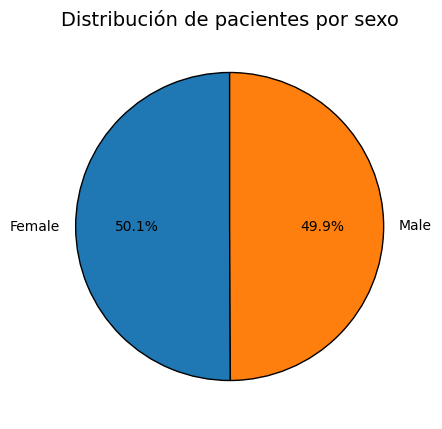

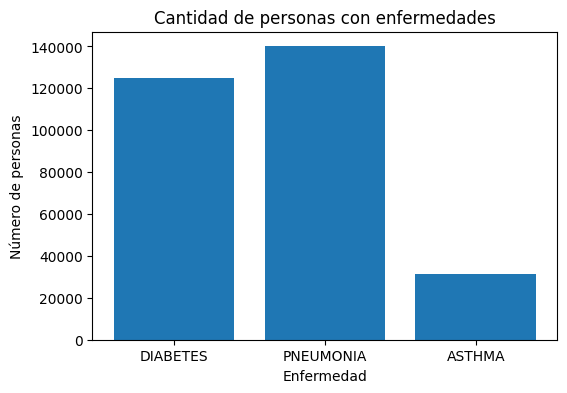

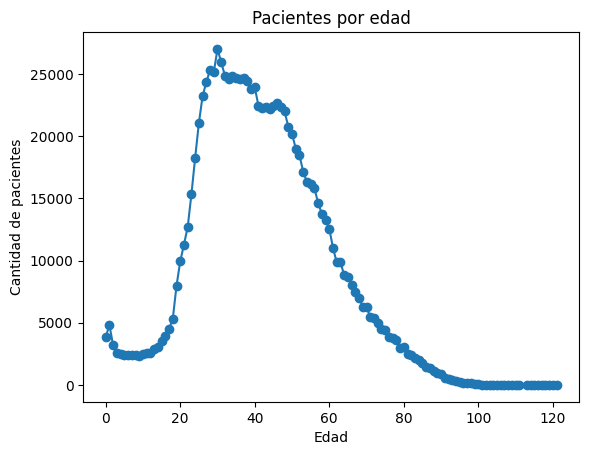

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

#compartimos el link de drive y lo dejamos en url
url = "https://drive.google.com/uc?export=download&id=16h4JzcD-fnVQltKLcSGMtwMJaL1lf-gA"
# separamos el csv por comas para que las columnas se vean claras
df = pd.read_csv(url, sep=';')

display(df.head())
#limpiamos el dataset columnas con muchos valores nulos y columnas que no nos sirven para el analisis en este caso si vimos el resultado
df.isnull().sum()
print(df.isnull().sum())
df = df.drop(df.columns[[0,1,16,17,18,19]],axis=1) #eliminamos filas con datos nulos

#aca imprimimos todas las columnas
print("columnas")
print(df.columns)
#imprimimos filas y columnas
print("Filas y columnas")
print(df.shape) #Nos deja ver el tamaño del dataset
#aca imprimimos estadistica descriptiva
df.describe() #Usamos todo en metodo de de variable numerica para tener mejores resultados
#ahora vamos a identificar outliers

# =========================
# 5. Calcular IQR
# =========================
Q1 = df["AGE"].quantile(0.25)
Q3 = df["AGE"].quantile(0.75)

IQR = Q3 - Q1
print("\nIQR:")
print(IQR)

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(limite_inferior,limite_superior)
# =========================
# 6. Detectar Outliers
# =========================
outliers = df[(df["AGE"] < limite_inferior) | (df["AGE"] > limite_superior)]
display(outliers)


#ahora graficamos pie y plot
conteo = df["SEX"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(conteo,labels=["Female","Male"],startangle=90,wedgeprops={"edgecolor":"black"}, autopct='%1.1f%%')

plt.title("Distribución de pacientes por sexo", fontsize=14)
plt.show()

diabetes = df["DIABETES"].value_counts()[1]
pneumonia = df["PNEUMONIA"].value_counts()[1]
asthma = df["ASTHMA"].value_counts()[1]

enfermedades = ["DIABETES", "PNEUMONIA", "ASTHMA"]
valores = [diabetes, pneumonia, asthma]

plt.figure(figsize=(6,4))
plt.bar(enfermedades, valores)

plt.title("Cantidad de personas con enfermedades")
plt.xlabel("Enfermedad")
plt.ylabel("Número de personas")

plt.show()

#Gráfica de puntos | Personas / Edad
edad = df["AGE"].value_counts().sort_index()

plt.plot(edad.index, edad.values, marker='o') #Crea la linea del gráfico por puntos

plt.title("Pacientes por edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad de pacientes")

plt.show()

















In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC # SVC rápido para datasets grandes
from sklearn.metrics import accuracy_score
import numpy as np


# PARTE 2: MODELADO E IMPORTANCIA DE VARIABLES



# 1. Preparar datos (X son todas las pistas, y es la meta)
X = df.drop(['PNEUMONIA'], axis=1)
y = df['PNEUMONIA']

# 2. Particionado 80/20 con Shuffle (Mezcla aleatoria)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=21)

# 3. Entrenamiento Inicial para detectar importancia
dt_inicial = DecisionTreeClassifier(max_depth=10, random_state=21)
dt_inicial.fit(X_train, y_train)

# 4. Cálculo y Impresión de importancia de TODAS las columnas
importancias = pd.Series(dt_inicial.feature_importances_, index=X.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

print("\n RANKING DE IMPORTANCIA DE TODAS LAS COLUMNAS:")
print(importancias_ordenadas)

# 5. Selección de las 2 mejores columnas
top_2_cols = importancias_ordenadas.head(2).index.tolist()
print(f" Las 2 columnas elegidas para el re-entrenamiento: {top_2_cols}")

# 6. Re-entrenamiento Final con los 3 modelos (Tuning)
X_train_top = X_train[top_2_cols]
X_test_top = X_test[top_2_cols]

# DT (Tuning max_depth)
dt_final = DecisionTreeClassifier(max_depth=10, random_state=21).fit(X_train_top, y_train)

# RF (Tuning n_estimators)
rf_final = RandomForestClassifier(n_estimators=100, random_state=21).fit(X_train_top, y_train)

# SVC (Linear/max_iter)
svc_final = LinearSVC(random_state=21, max_iter=1000).fit(X_train_top, y_train)

# 7. RESULTADOS FINALES DE ACCURACY
print("\n RESULTADOS DE CLASIFICACIÓN (Solo Top 2):")
print(f"Accuracy Decision Tree: {dt_final.score(X_test_top, y_test):.4f}")
print(f"Accuracy Random Forest: {rf_final.score(X_test_top, y_test):.4f}")
print(f"Accuracy SVC (Linear):  {svc_final.score(X_test_top, y_test):.4f}")




 RANKING DE IMPORTANCIA DE TODAS LAS COLUMNAS:
PATIENT_TYPE      0.948270
AGE               0.033213
OBESITY           0.004033
SEX               0.003577
DIABETES          0.003043
OTHER_DISEASE     0.001489
RENAL_CHRONIC     0.001209
HIPERTENSION      0.001102
ASTHMA            0.000960
INMSUPR           0.000924
COPD              0.000923
TOBACCO           0.000707
CARDIOVASCULAR    0.000552
dtype: float64
 Las 2 columnas elegidas para el re-entrenamiento: ['PATIENT_TYPE', 'AGE']

 RESULTADOS DE CLASIFICACIÓN (Solo Top 2):
Accuracy Decision Tree: 0.8924
Accuracy Random Forest: 0.8924
Accuracy SVC (Linear):  0.8889


In [ ]:
# =========================
# 4. Cross Validation
# =========================

#Que es Cross Validation?
#El Cross Validation es una técnica para evaluar modelos de machine learning

#Que hace Cross Validation?
#Hace todo automáticamente:
#Divide los datos
#Entrena el modelo
#Evalúa
#Devuelve los resultados

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import warnings
warnings.filterwarnings('ignore')

# --- Cargar y limpiar dataset ---
url = "https://drive.google.com/uc?export=download&id=16h4JzcD-fnVQltKLcSGMtwMJaL1lf-gA"
df = pd.read_csv(url, sep=';')
df = df.drop(df.columns[[0,1,16,17,18,19]], axis=1)
df = df.dropna()

# --- Muestra de 3000 filas para que corra rápido ---
df_sample = df.sample(n=3000, random_state=21)
X = df_sample.drop(['PNEUMONIA'], axis=1).select_dtypes(include=[np.number])
y = df_sample['PNEUMONIA']

# --- Modelos ---"Definimos los modelos"
dt  = DecisionTreeClassifier(max_depth=5, random_state=21)
rf  = RandomForestClassifier(n_estimators=10, random_state=21)
svc = LinearSVC(random_state=42, max_iter=500)#Support Vector Classifier(Clasificador de Vectores de Soporte)

# --- Cross Validation k=10, 20, 50 ---"Probamos 3 configuraciones de k"
for k in [10, 20, 50]:
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=21)#divide los datos en k (folds)
    dt_scores  = cross_val_score(dt,  X, y, cv=kf, scoring='accuracy')#10 es estandar
    rf_scores  = cross_val_score(rf,  X, y, cv=kf, scoring='accuracy')#20 es mas preciso
    svc_scores = cross_val_score(svc, X, y, cv=kf, scoring='accuracy')#50 es exigente

    print(f"\n===== CROSS VALIDATION (k={k}) =====")
    print(f"Decision Tree  -> Promedio: {dt_scores.mean():.4f} | Std: {dt_scores.std():.4f}")#Promedio(accuracy) → rendimiento general
    print(f"Random Forest  -> Promedio: {rf_scores.mean():.4f} | Std: {rf_scores.std():.4f}")#Desviación estándar → estabilidad
    print(f"SVC Lineal     -> Promedio: {svc_scores.mean():.4f} | Std: {svc_scores.std():.4f}")


===== CROSS VALIDATION (k=10) =====
Decision Tree  -> Promedio: 0.8777 | Std: 0.0158
Random Forest  -> Promedio: 0.8723 | Std: 0.0144
SVC Lineal     -> Promedio: 0.8860 | Std: 0.0113

===== CROSS VALIDATION (k=20) =====
Decision Tree  -> Promedio: 0.8743 | Std: 0.0192
Random Forest  -> Promedio: 0.8680 | Std: 0.0234
SVC Lineal     -> Promedio: 0.8857 | Std: 0.0206

===== CROSS VALIDATION (k=50) =====
Decision Tree  -> Promedio: 0.8790 | Std: 0.0318
Random Forest  -> Promedio: 0.8717 | Std: 0.0353
SVC Lineal     -> Promedio: 0.8860 | Std: 0.0326


In [ ]:
# PUNTO 5 - DEEP LEARNING
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(21); tf.keras.utils.set_random_seed(21); np.random.seed(21)

url = "https://drive.google.com/uc?export=download&id=16h4JzcD-fnVQltKLcSGMtwMJaL1lf-gA"
df = pd.read_csv(url, sep=';')
df = df.drop(df.columns[[0,1,16,17,18,19]], axis=1)
df = df.dropna()

df_sample = df.sample(n=3000, random_state=21)
X = df_sample.drop(['PNEUMONIA'], axis=1).select_dtypes(include=[np.number])
y = df_sample['PNEUMONIA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

arquitecturas = {
    'Config1 - 3 capas  (64, 128, 128)':              (64, 128, 128),
    'Config2 - 6 capas  (64,64,128,128,256,256)':      (64, 64, 128, 128, 256, 256),
    'Config3 - 10 capas (128 neuronas cada una)':      (128,)*10
}

print("===== PUNTO 5 - DEEP LEARNING: PERCEPTRÓN MULTICAPA =====\n")
mejor_acc = 0
mejor_config = ""

for nombre, capas in arquitecturas.items():
    for epocas in [10, 50, 100]:
        tf.keras.utils.set_random_seed(21)
        model = tf.keras.Sequential(
            [tf.keras.layers.Dense(n, activation='relu') for n in capas] +
            [tf.keras.layers.Dense(1, activation='sigmoid')]
        )
        model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
        model.fit(X_train, y_train, epochs=epocas, verbose=0)
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"{nombre} | Épocas: {epocas:3d} -> Accuracy: {acc*100:.2f}%")

        if acc > mejor_acc:
            mejor_acc = acc
            mejor_config = f"{nombre} | Épocas: {epocas}"

print(f"\n Época más conveniente: {mejor_config}")
print(f" Accuracy obtenido:     {mejor_acc*100:.2f}%")

===== PUNTO 5 - DEEP LEARNING: PERCEPTRÓN MULTICAPA =====

Config1 - 3 capas  (64, 128, 128) | Épocas:  10 -> Accuracy: 11.50%
Config1 - 3 capas  (64, 128, 128) | Épocas:  50 -> Accuracy: 11.50%
Config1 - 3 capas  (64, 128, 128) | Épocas: 100 -> Accuracy: 11.50%
Config2 - 6 capas  (64,64,128,128,256,256) | Épocas:  10 -> Accuracy: 11.50%
Config2 - 6 capas  (64,64,128,128,256,256) | Épocas:  50 -> Accuracy: 11.50%
Config2 - 6 capas  (64,64,128,128,256,256) | Épocas: 100 -> Accuracy: 11.50%
Config3 - 10 capas (128 neuronas cada una) | Épocas:  10 -> Accuracy: 0.00%
Config3 - 10 capas (128 neuronas cada una) | Épocas:  50 -> Accuracy: 0.00%
Config3 - 10 capas (128 neuronas cada una) | Épocas: 100 -> Accuracy: 0.00%

 Época más conveniente: Config1 - 3 capas  (64, 128, 128) | Épocas: 10
 Accuracy obtenido:     11.50%


TERCERA PARTE( APRENDIZAJE NO SUPERVISADO Y REDUCCIÒN DE DIMENSIONALIDAD )


**PCA**

Varianza total explicada: 0.27216551555944785


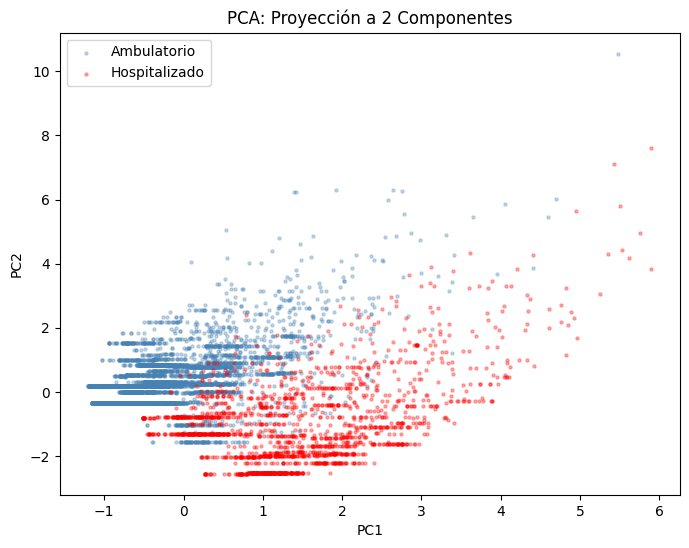

In [ ]:


import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# =====================================================================
# CARGA COMPLETA DESDE CERO
# =====================================================================
url = "https://drive.google.com/uc?export=download&id=16h4JzcD-fnVQltKLcSGMtwMJaL1lf-gA"
df = pd.read_csv(url, sep=';')

# Guardar etiqueta ANTES de eliminar columnas
etiqueta_col = 'PATIENT_TYPE'
etiqueta = df[etiqueta_col].copy()

# Eliminar columnas no deseadas
df = df.drop(df.columns[[0, 1, 16, 17, 18, 19]], axis=1, errors='ignore')
df['ETIQUETA'] = etiqueta  # re-agregar etiqueta temporalmente

# Limpieza
df = df.replace([97, 98, 99], pd.NA)
df = df.dropna()

# Muestreo
df_sample = df.sample(n=min(10000, len(df)), random_state=21)

# Separar X e y
y = df_sample['ETIQUETA'].values
X = df_sample.drop('ETIQUETA', axis=1).values

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, whiten=True)
X_pca = pca.fit_transform(X_scaled)

print('Varianza total explicada:', pca.explained_variance_ratio_.sum())

# Gráfico con 2 colores
plt.figure(figsize=(8, 6))
for clase, color, label in [(1, 'steelblue', 'Ambulatorio'),
                             (2, 'red', 'Hospitalizado')]:
    mask = y == clase
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                alpha=0.3, s=5, c=color, label=label)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: Proyección a 2 Componentes')
plt.legend()
plt.show()

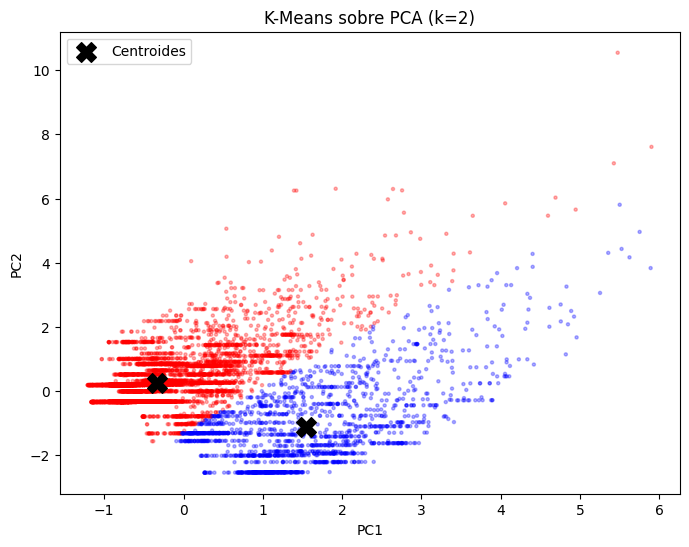

In [ ]:
from sklearn.cluster import KMeans

# =====================================================================
# KMEANS SOBRE X_PCA
# =====================================================================
kmeans = KMeans(n_clusters=2, random_state=21, n_init=10)
kmeans.fit(X_pca)
labels = kmeans.labels_

# =====================================================================
# VISUALIZACIÓN
# =====================================================================
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels,
                      cmap='bwr',
                      alpha=0.3, s=5)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            c='black', marker='X', s=200, label='Centroides')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means sobre PCA (k=2)')
plt.legend()
plt.show()



Clusters encontrados: 3
Puntos de ruido: 128
Total puntos: 5000


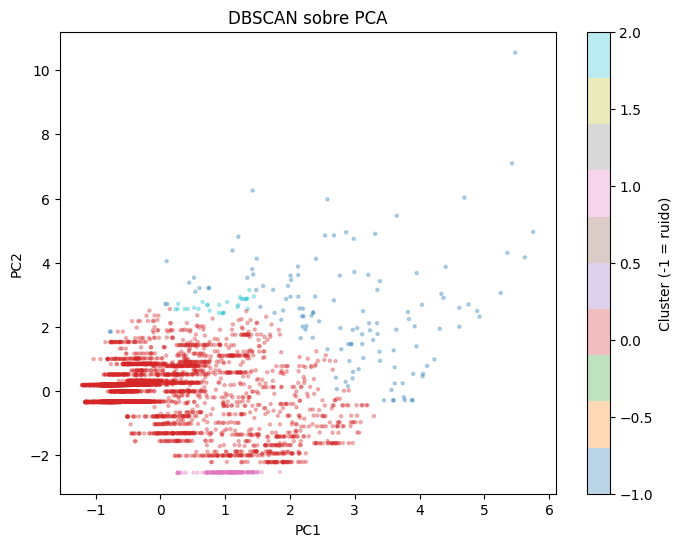

In [ ]:
# =====================================================================
# DBSCAN CON MUESTRA REDUCIDA
# =====================================================================
from sklearn.cluster import DBSCAN

# Usar solo 5,000 puntos para DBSCAN
X_pca_small = X_pca[:5000]

dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan.fit(X_pca_small)
labels_db = dbscan.labels_

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido = (labels_db == -1).sum()

print(f'Clusters encontrados: {n_clusters}')
print(f'Puntos de ruido: {n_ruido}')
print(f'Total puntos: {len(labels_db)}')
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_small[:, 0], X_pca_small[:, 1],
            c=labels_db,
            cmap='tab10',
            alpha=0.3, s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN sobre PCA')
plt.colorbar(label='Cluster (-1 = ruido)')
plt.show()